In [20]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("tableau-colorblind10")

Final losses:
Newton: 12.182929165347916
Gradient: 12.183701558805065
MU: 12.345601695991274


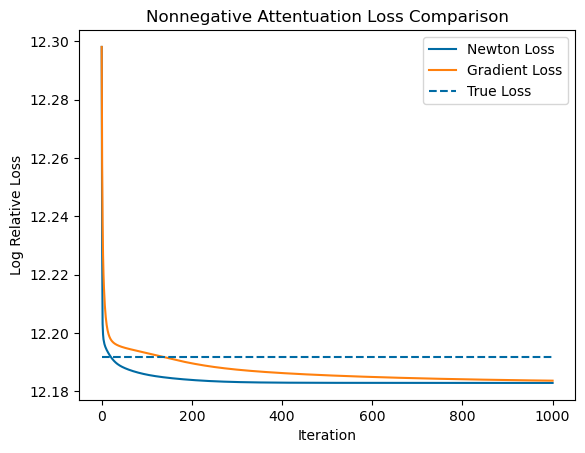

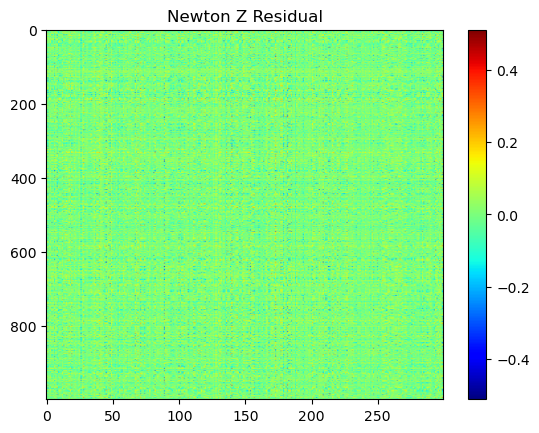

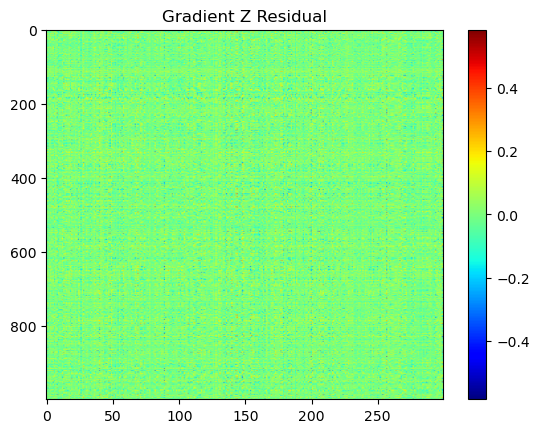

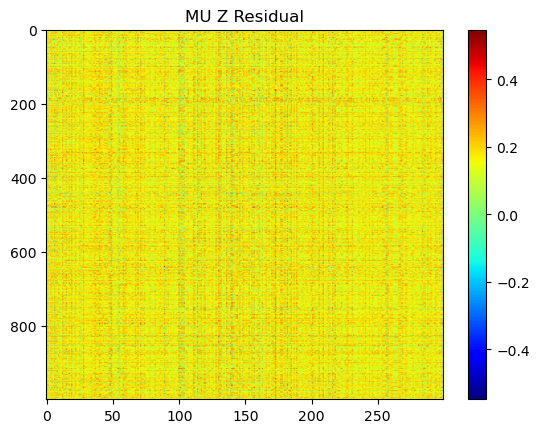

In [ ]:
m = 1000
n = 300
k = 5
I_0 = 2e0

EPS = 1e-10

A = np.random.rand(m, k)
B = np.random.rand(k, n)
Z = np.exp(-A @ B)
T = np.random.poisson(I_0 * Z) / I_0

def loss(A_hat, B_hat):
    V = A @ B
    V_hat = A_hat @ B_hat
    return np.log(np.sum(np.exp(-V_hat) + T * V_hat))# / np.sum(np.exp(-V) + T * V))

def newton_step(A_hat, B_hat, learning_rate):
    V_hat = A_hat @ B_hat
    Z_hat = np.exp(-V_hat)

    dL_dA = (T - Z_hat) @ B_hat.T
    dL_dB = A_hat.T @ (T - Z_hat)

    d2L_dA2 = Z_hat @ B_hat.T**2
    d2L_dB2 = A_hat.T**2 @ Z_hat

    A_new = np.maximum(A_hat - learning_rate * dL_dA / (d2L_dA2), EPS)
    B_new = np.maximum(B_hat - learning_rate * dL_dB / (d2L_dB2), EPS)
    return A_new, B_new

def gradient_step(A_hat, B_hat, learning_rate):
    V_hat = A_hat @ B_hat
    Z_hat = np.exp(-V_hat)

    dL_dA = (T - Z_hat) @ B_hat.T
    dL_dB = A_hat.T @ (T - Z_hat)

    A_new = np.maximum(A_hat - learning_rate * dL_dA, EPS)
    B_new = np.maximum(B_hat - learning_rate * dL_dB, EPS)
    return A_new, B_new

def mu_step(A_hat, B_hat):
    V_hat = A_hat @ B_hat
    Z_hat = np.exp(-V_hat)

    A_mult = (Z_hat @ B_hat.T) / (T @ B_hat.T + EPS)
    B_mult = (A_hat.T @ Z_hat) / (A_hat.T @ T + EPS)

    A_new = np.maximum(A_hat * A_mult, EPS)
    B_new = np.maximum(B_hat * B_mult, EPS)
    return A_new, B_new

A_newton = np.random.rand(m, k)
B_newton = np.random.rand(k, n)

A_gradient = A_newton.copy()
B_gradient = B_newton.copy()

A_mu = A_newton.copy()
B_mu = B_newton.copy()

losses = [[loss(A_newton, B_newton)], [loss(A_gradient, B_gradient)], [loss(A_mu, B_mu)]]
for i in range(1000):
    A_newton, B_newton = newton_step(A_newton, B_newton, learning_rate=0.2)
    A_gradient, B_gradient = gradient_step(A_gradient, B_gradient, learning_rate=0.001)
    A_mu, B_mu = mu_step(A_mu, B_mu)

    losses[0].append(loss(A_newton, B_newton))
    losses[1].append(loss(A_gradient, B_gradient))
    losses[2].append(loss(A_mu, B_mu))

print(f"Final losses:\nNewton: {losses[0][-1]}\nGradient: {losses[1][-1]}\nMU: {losses[2][-1]}")
plt.plot(losses[0], label='Newton Loss')
plt.plot(losses[1], label='Gradient Loss')
plt.plot(losses[2], label='MU Loss')
plt.hlines(loss(A, B), 0, len(losses[0])-1, linestyle='dashed', label='True Loss')
plt.legend()
plt.xlabel('Iteration')
plt.ylabel('Log Relative Loss')
plt.title('Nonnegative Attentuation Loss Comparison')
plt.show()

Z_res_newton = Z - np.exp(-A_newton @ B_newton)
Z_res_gradient = Z - np.exp(-A_gradient @ B_gradient)
Z_res_mu = Z - np.exp(-A_mu @ B_mu)

plt.imshow(Z_res_newton, aspect='auto', cmap='jet', vmin=-np.abs(Z_res_newton).max(), vmax=np.abs(Z_res_newton).max())
plt.colorbar()
plt.title('Newton Z Residual')
plt.show()

plt.imshow(Z_res_gradient, aspect='auto', cmap='jet', vmin=-np.abs(Z_res_gradient).max(), vmax=np.abs(Z_res_gradient).max())
plt.colorbar()
plt.title('Gradient Z Residual')
plt.show()

plt.imshow(Z_res_mu, aspect='auto', cmap='jet', vmin=-np.abs(Z_res_mu).max(), vmax=np.abs(Z_res_mu).max())
plt.colorbar()
plt.title('MU Z Residual')
plt.show()